# Stability Analysis - Demo_BESS Parameter Sweep

This notebook sweeps one parameter of `Demo_BESS`, linearizes the model at each value, and analyzes the eigenvalues to track how the modes and their stability change across the sweep.

Set `REINITIALIZE_EACH_CASE` to choose whether the model is initialized once before the sweep, or reinitialized after each parameter update.

In [1]:
include("../scripts/dictionaries.jl")
include("../scripts/helpers.jl")
include("../scripts/parametric_study_helpers.jl")
include("../scripts/single_model_initialization.jl")
include("scripts/linearize_scripting.jl")

using .WorkflowHelpers
using .ModelInitialization
using OMJulia, LinearAlgebra, DataFrames


## User Configuration

Choose the model, the parameter to sweep and its values, and the linearization settings here.

In [2]:
BASE_MODEL = "Demo_BESS"
BASE_MODEL_FILE = abspath("models/Demo_BESS.mo")

OMLIB_DIR = joinpath(homedir(), ".openmodelica", "libraries")
ENV["OPENMODELICALIBRARY"] = OMLIB_DIR
MODELICA_PKG_PATH = joinpath(OMLIB_DIR, "Modelica 3.2.3+maint.om", "package.mo")
DYNAWO_PKG_PATH = abspath("../dynawo_library/Dynawo/package.mo")

SWEEP_COMPONENT = "BESS"
SWEEP_PARAMETER = "Kpg"
SWEEP_VALUES = [1.0, 2.0, 3.0, 5.0, 7.0, 10.0]

REINITIALIZE_EACH_CASE = true

LINEARIZATION_TIME = "2.0"
MODE_TOL = 1e-8

INIT_MODEL_BY_COMPONENT = Dict{String, String}()

# Leave empty to disable slack-specific handling.
SLACK_COMPONENT = ""

OUTPUT_DIR = abspath("outputs/Demo_BESS_Kpg_stability_sweep");


## Prepare OpenModelica Session

The output folders are created and the library paths are checked before the run.

In [3]:
BUILD_OUTPUT_DIR = joinpath(OUTPUT_DIR, "omc-build")

isfile(BASE_MODEL_FILE) || error("Base model file not found: $BASE_MODEL_FILE")
isfile(DYNAWO_PKG_PATH) || error("Dynawo package not found: $DYNAWO_PKG_PATH")
isfile(MODELICA_PKG_PATH) || error("Modelica package not found: $MODELICA_PKG_PATH")

rm(OUTPUT_DIR; recursive = true, force = true)
mkpath(BUILD_OUTPUT_DIR)

StudyOMC = OMJulia.OMCSession()
load_modelica_file!(
    StudyOMC,
    BASE_MODEL_FILE,
    MODELICA_PKG_PATH,
    DYNAWO_PKG_PATH,
)
check_user_configuration_single(StudyOMC;
    model = BASE_MODEL,
    sweep_component = SWEEP_COMPONENT,
    sweep_parameter = SWEEP_PARAMETER,
    slack_component = SLACK_COMPONENT,
    init_model_by_component = INIT_MODEL_BY_COMPONENT,
)


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.foPBAk44RD"


Configuration checked successfully


## Initialize the Base Case

When `REINITIALIZE_EACH_CASE` is `false`, initialize the base model once here and reuse it for every sweep case. When it is `true`, this cell only closes the session opened above.

In [4]:
if !REINITIALIZE_EACH_CASE
    base_initialized_case = initialize_loaded_model(
        StudyOMC;
        source_model = BASE_MODEL,
        case_name = BASE_MODEL,
        output_dir = OUTPUT_DIR,
        modelica_package_path = MODELICA_PKG_PATH,
        dynawo_package_path = DYNAWO_PKG_PATH,
        init_model_by_component = INIT_MODEL_BY_COMPONENT,
        slack_component = SLACK_COMPONENT,
    )

    base_initialized_model = base_initialized_case.initialized_model
    base_initialized_model_file = base_initialized_case.initialized_model_file
    println("Base case initialized once: ", base_initialized_model)
end

OMJulia.quit(StudyOMC)

## Run the Parameter Sweep

For each parameter value the model is initialized, linearized, and its state-space matrix is stored.

In [5]:
A_matrices = Dict{Float64, Matrix{Float64}}()
linear_states_by_case = Dict{Float64, Vector{String}}()
linearization_sizes = NamedTuple[]

for value in SWEEP_VALUES
    label = case_label(value)
    parameter_name = replace(SWEEP_PARAMETER, "." => "_")
    case_model = join([BASE_MODEL, SWEEP_COMPONENT, parameter_name, label], "_")
    case_build_dir = joinpath(BUILD_OUTPUT_DIR, case_model)
    mkpath(case_build_dir)

    StudyOMC = OMJulia.OMCSession()

    try
        if REINITIALIZE_EACH_CASE
            load_modelica_file!(
                StudyOMC,
                BASE_MODEL_FILE,
                MODELICA_PKG_PATH,
                DYNAWO_PKG_PATH,
            )

            omc_call(
                StudyOMC,
                "setParameterValue($(BASE_MODEL), $(SWEEP_COMPONENT).$(SWEEP_PARAMETER), $(string(value)))",
                parsed = false,
            )

            initialized_case = initialize_loaded_model(
                StudyOMC;
                source_model = BASE_MODEL,
                case_name = case_model,
                output_dir = OUTPUT_DIR,
                modelica_package_path = MODELICA_PKG_PATH,
                dynawo_package_path = DYNAWO_PKG_PATH,
                init_model_by_component = INIT_MODEL_BY_COMPONENT,
                slack_component = SLACK_COMPONENT,
            )

            linearized_model = initialized_case.initialized_model
        else
            load_modelica_file!(
                StudyOMC,
                base_initialized_model_file,
                MODELICA_PKG_PATH,
                DYNAWO_PKG_PATH,
            )

            omc_call(
                StudyOMC,
                "setParameterValue($(base_initialized_model), $(SWEEP_COMPONENT).$(SWEEP_PARAMETER), $(string(value)))",
                parsed = false,
            )

            linearized_model = base_initialized_model
        end

        matrices = linearize_scripting(
            StudyOMC,
            linearized_model;
            startTime = 0.0,
            stopTime = parse(Float64, LINEARIZATION_TIME),
            stepSize = 0.001,
            tolerance = 1e-6,
            outdir = case_build_dir,
        )

        A_matrices[value] = matrices.A
        linear_states_by_case[value] = matrices.states

        if value == first(SWEEP_VALUES)
            push!(linearization_sizes, (
                A = join(string.(size(matrices.A)), "x"),
                B = join(string.(size(matrices.B)), "x"),
                C = join(string.(size(matrices.C)), "x"),
                D = join(string.(size(matrices.D)), "x"),
            ))
        end
    finally
        OMJulia.quit(StudyOMC)
    end

    println("Finished $SWEEP_COMPONENT.$SWEEP_PARAMETER = $value")
end

linear_states = linear_states_by_case[first(SWEEP_VALUES)]

for value in SWEEP_VALUES
    if linear_states_by_case[value] != linear_states
        error("Linear state order changed for $SWEEP_COMPONENT.$SWEEP_PARAMETER = $value")
    end
end

println("Linearization sweep finished.")


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.BJzqXZhco2"


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.nLTvpJxVXo"


Finished BESS.Kpg = 1.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.iKhHjSoTp2"


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.azFn1fueV5"


...

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.RViYm7VKtc"


Finished BESS.Kpg = 7.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.4TikGmLRJ2"


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.hrhYKupHFs"


Finished BESS.Kpg = 10.0
Linearization sweep finished.


## Linearization Summary

The dimensions of the linearized system are reported for one case as a sanity check.

In [6]:
sizes = linearization_sizes[1]

linearization_summary = DataFrame([(
    n_states = length(linear_states),
    size_A = sizes.A,
    size_B = sizes.B,
    size_C = sizes.C,
    size_D = sizes.D,
)])

display(linearization_summary)


Row,n_states,size_A,size_B,size_C,size_D
,Int64,String,String,String,String
1,20,20x20,20x0,0x20,0x0


## Analyze Modes

The modes of each case are computed and classified as stable, marginal, or unstable.

In [7]:
mode_rows = NamedTuple[]
summary_rows = NamedTuple[]

for value in SWEEP_VALUES
    A = A_matrices[value]

    eigenvalues = eigvals(A)
    real_parts = real.(eigenvalues)

    for (mode_index, lambda) in enumerate(eigenvalues)
        real_part = real(lambda)
        imag_part = imag(lambda)

        stability = if real_part > MODE_TOL
            "unstable"
        elseif real_part < -MODE_TOL
            "stable"
        else
            "marginal"
        end

        push!(mode_rows, (
            parameter_value = value,
            mode = mode_index,
            real_part = real_part,
            imag_part = imag_part,
            stability = stability,
        ))
    end

    push!(summary_rows, (
        parameter_value = value,
        max_real_part = maximum(real_parts),
        unstable_modes = count(real_parts .> MODE_TOL),
        marginal_modes = count(abs.(real_parts) .<= MODE_TOL),
        stable_modes = count(real_parts .< -MODE_TOL),
    ))
end

mode_df = sort(DataFrame(mode_rows), [:parameter_value, :mode])
stability_summary = sort(DataFrame(summary_rows), :parameter_value)

println("Mode analysis finished.")


Mode analysis finished.


## Check Unstable Modes

The modes that become unstable across the sweep are identified.

In [8]:
unstable_modes = Int[]

for mode in sort(unique(mode_df.mode))
    rows_for_mode = mode_df[mode_df.mode .== mode, :]

    if any(rows_for_mode.stability .== "unstable")
        push!(unstable_modes, mode)
    end
end

unstable_mode_table = DataFrame(mode = unstable_modes)

for value in SWEEP_VALUES
    column_name = Symbol("$SWEEP_PARAMETER=$(value)")
    stability_values = String[]

    for mode in unstable_modes
        rows_for_mode = mode_df[(mode_df.mode .== mode) .& (mode_df.parameter_value .== value), :]
        push!(stability_values, rows_for_mode.stability[1])
    end

    unstable_mode_table[!, column_name] = stability_values
end

unstable_mode_rows = in.(mode_df.mode, Ref(unstable_modes))
unstable_mode_df = sort(mode_df[unstable_mode_rows, :], [:mode, :parameter_value])

println("Unstable-mode check finished.")


Unstable-mode check finished.


## Modes

The stability summary and the unstable modes are displayed.

In [9]:
println("Stability summary")
display(stability_summary)

println("Modes that become unstable")
display(unstable_mode_table)


Stability summary


Row,parameter_value,max_real_part,unstable_modes,marginal_modes,stable_modes
,Float64,Float64,Int64,Int64,Int64
1,1.0,0.0,0,3,17
2,2.0,0.0,0,3,17
3,3.0,0.0,0,3,17
4,5.0,0.0,0,3,17
5,7.0,0.380722,2,3,15
6,10.0,3.15468,2,3,15


Modes that become unstable


Row,mode,Kpg=1.0,Kpg=2.0,Kpg=3.0,Kpg=5.0,Kpg=7.0,Kpg=10.0
,Int64,String,String,String,String,String,String
1,19,marginal,marginal,marginal,marginal,unstable,unstable
2,20,marginal,marginal,marginal,marginal,unstable,unstable


## Mode Plots

The unstable modes are plotted in the complex plane across the sweep.

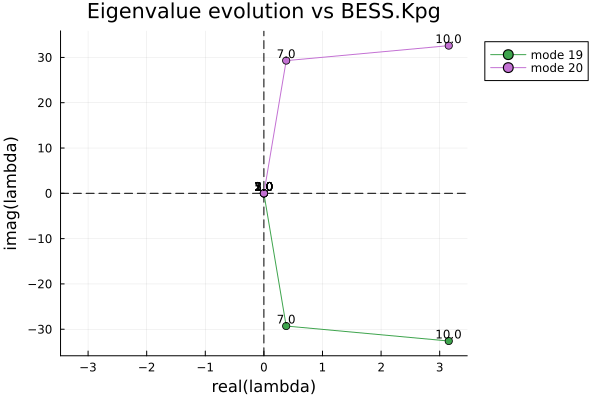

In [10]:
using Plots


if isempty(unstable_modes)
    println("No modes become unstable for these sweep values.")
else
    # symmetric limits centred on the origin so all four quadrants are visible
    r_lim = 1.1 * maximum(abs.(unstable_mode_df.real_part))
    i_lim = 1.1 * maximum(abs.(unstable_mode_df.imag_part))

    locus_plot = plot(
        xlabel = "real(lambda)",
        ylabel = "imag(lambda)",
        title = "Eigenvalue evolution vs $SWEEP_COMPONENT.$SWEEP_PARAMETER",
        legend = :outertopright,
        xlims = (-r_lim, r_lim),
        ylims = (-i_lim, i_lim),
    )
    vline!(locus_plot, [0.0], line = (:dash, :black), label = "")  # Re = 0  (stability boundary)
    hline!(locus_plot, [0.0], line = (:dash, :black), label = "")  # Im = 0

    for mode in unstable_modes
        mode_data = unstable_mode_df[unstable_mode_df.mode .== mode, :]
        plot!(
            locus_plot,
            mode_data.real_part,
            mode_data.imag_part,
            marker = :circle,
            label = "mode $mode",
            series_annotations = text.(string.(mode_data.parameter_value), 8, :bottom),
        )
    end

    display(locus_plot)
end
